In [1]:
# 1. Import libraries
# ==========================================

import time
from datetime import timedelta

import joblib
import pandas as pd

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# 2. Load data
# ==========================================

df = pd.read_csv('Loan_Data.csv')
df.columns = df.columns.str.strip()


# 3. Select 6 features and target
# ==========================================

numeric_features = [
    'person_age',
    'person_income',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income']

categorical_features = ['previous_loan_defaults_on_file']

all_features = numeric_features + categorical_features
target_column = 'loan_status'


# 4. Prepare data
# ==========================================

data = df[all_features + [target_column]].dropna().copy()
data['previous_loan_defaults_on_file'] = (data['previous_loan_defaults_on_file'].map({'No': 0,'Yes': 1}))

# Check that all values were converted successfully
if data['previous_loan_defaults_on_file'].isna().any():
    raise ValueError('The defaults column contains values other than Yes or No')

# Separate features and target
X = data[all_features]
y = data[target_column]


# 5. Split data into 80% training and 20% testing sets
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'📊Total rows: {len(data)}')
print(f'📊Training samples: {len(X_train)}')
print(f'📊Testing samples: {len(X_test)}')



# 6. Build Pipeline
# ==========================================

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier",SVC(kernel="rbf", C=1.0, probability=True, random_state=42))
])

# 7. Train model
# ==========================================

print(f'🚀 Training the model, please wait...')

start_time = time.time()

pipeline.fit(X_train, y_train)

elapsed_time = timedelta(seconds=int(time.time() - start_time))

print(f'\n✓ Training completed in {elapsed_time}')


# 8. Evaluate model
# ==========================================

y_pred = pipeline.predict(X_test)

print(f'\n🎯Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}')

print(f'\n🎯Accuracy: {accuracy_score(y_test, y_pred):.4f}')

print(f'\n🎯Classification Report:\n {classification_report(y_test, y_pred)}')


# 9. Save complete Pipeline
# ==========================================

model_filename = 'loan_svc_model_v1.0.pkl'

joblib.dump(pipeline, model_filename)

print(f'\n💾Model saved successfully as {model_filename}')

📊Total rows: 45000
📊Training samples: 36000
📊Testing samples: 9000
🚀 Training the model, please wait...

✓ Training completed in 0:01:57

🎯Confusion Matrix:
 [[6620  380]
 [ 514 1486]]

🎯Accuracy: 0.9007

🎯Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      7000
           1       0.80      0.74      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000


💾Model saved successfully as loan_svc_model_v1.0.pkl


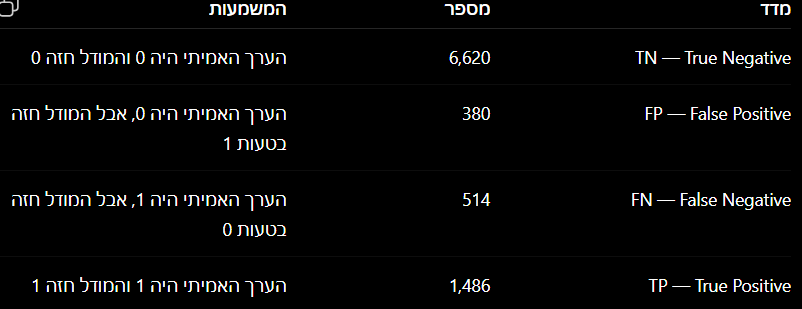

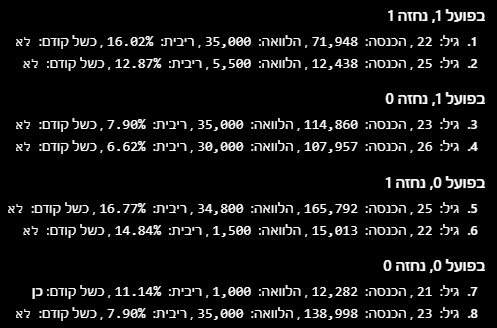